# Packages

In [1]:
import Pkg
Pkg.add("Gen")
Pkg.add("Plots")
Pkg.add("StatsBase")
Pkg.add("StatsPlots")
Pkg.add("Distributions")
Pkg.add("StatsFuns")
Pkg.add(url="https://github.com/probcomp/GenVariableElimination.jl")

In [2]:
using Gen, Plots, Distributions, StatsPlots, LinearAlgebra, StatsFuns, Printf
using StatsBase: mean, countmap
using Distributions: Categorical
using GenVariableElimination: compile_trace_to_factor_graph, variable_elimination,
                             Latent, Observation, conditional_dist
using StatsFuns: logsumexp

# RSA model: Politeness - the case study of white lies

Version 1: Using VE‐based inference by `GenVariableElimination.jl`

## L0

In [3]:
using Gen

# Define state and utterance space
states = [1, 2, 3, 4, 5]
utterances = ["terrible", "bad", "okay", "good", "amazing"]
key_mapping = Dict("terrible" => 1, "bad" => 2, "okay" => 3, "good" => 4, "amazing" => 5)

# Literal semantics represented as probabilities
literalSemantics = Dict(
    "terrible" => [0.95, 0.85, 0.02, 0.02, 0.02],
    "bad" => [0.85, 0.95, 0.02, 0.02, 0.02],
    "okay" => [0.02, 0.25, 0.95, 0.65, 0.35],
    "good" => [0.02, 0.05, 0.55, 0.95, 0.93],
    "amazing" => [0.02, 0.02, 0.02, 0.65, 0.95]
)

prob(utterance::String, state::Int64) = literalSemantics[utterance][state]
@dist meaning(utterance::String, state::Int64) = bernoulli(prob(utterance, state))

@dist uniformDraw(vector::Vector, vectorProbs::Vector{Float64}) = vector[categorical(vectorProbs)]
uniformProbs(vector::Vector) = fill(1 / length(vector), length(vector))
stateProbs = uniformProbs(states)
utterancesProbs = uniformProbs(utterances)

@gen function literalListener(stateProbs::Vector{Float64}, utterance::String)
    state = @trace(uniformDraw(states, stateProbs), :state)
    m = @trace(meaning(utterance, state), :m)
    return state
end

DynamicDSLFunction{Any}(Dict{Symbol, Any}(), Dict{Symbol, Any}(), Type[Vector{Float64}, String], false, Union{Nothing, Some{Any}}[nothing, nothing], var"##literalListener#227", Bool[0, 0], false)

In [4]:
"""
    ve_enum_inference(
      model, model_args,
      observations::ChoiceMap,
      latent_addrs::NTuple{N,Any},
      latent_values::NTuple{N,AbstractVector}
    ) where {N}

Exact posterior over discrete latents via variable elimination.
Returns `Dict(addr ⇒ posterior_vector)`.
"""
function ve_enum_inference(
    model::GenerativeFunction, model_args::Tuple,
    observations::ChoiceMap,
    latent_addrs::NTuple{N,Any},
    latent_values::NTuple{N,AbstractVector}
  ) where {N}

  # one constrained generate() to get a template trace
  tr, _ = generate(model, model_args, observations)

  # build the Latent / Observation metadata
  addrs = Tuple(latent_addrs)
  vals  = Tuple(latent_values)
  latents = Dict{Any,Latent}()
  for (addr, vs) in zip(addrs, vals)
    latents[addr] = Latent(vs, [])    # in this simple, no extra parents
  end

  # only :m depends on :state
  observations_meta = Dict{Any,Observation}(
    :m => Observation([:state])
  )

  # compile and eliminate
  fg      = compile_trace_to_factor_graph(tr, latents, observations_meta)
  elimord = collect(addrs)                   # heuristic_order(fg,:min_fill) might also work?
  ve_res  = variable_elimination(fg, elimord)

  # read posteriors via conditional_dist
  post = Dict{Any,Vector{Float64}}()
  dummy = Vector{Any}(undef, N)
  for (i, addr) in enumerate(addrs)
    idx             = fg.addr_to_idx[addr]
    intermediate_fg = ve_res.intermediate_fgs[idx]
    post[addr]      = conditional_dist(intermediate_fg, dummy, addr)
  end

  return post
end

# Define observed action
utterance   = "good"
observations = choicemap(:m => true)   # fix the observed :m choice

# Now run the VE‐based inference
results = ve_enum_inference(
  literalListener,
  (stateProbs, utterance),
  observations,
  (:state,),   # latent addresses
  (states,)    # values each latent can take
)

Dict{Any, Vector{Float64}} with 1 entry:
  :state => [0.008, 0.02, 0.22, 0.38, 0.372]

In [5]:
for (s,p) in zip(states, results[:state])
  @printf("  state %d → %.4f\n", s, p)
end

  state 1 → 0.0080
  state 2 → 0.0200
  state 3 → 0.2200
  state 4 → 0.3800
  state 5 → 0.3720


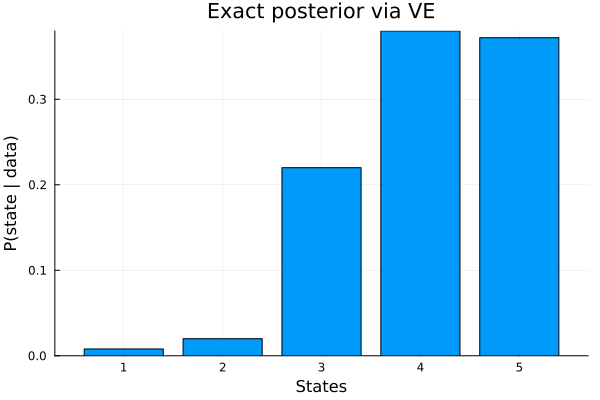

In [6]:
bar(
  states, results[:state],
  xlabel="States", ylabel="P(state | data)",
  legend=false, title="Exact posterior via VE"
)

## S1

In [7]:
using GenVariableElimination:
    compile_trace_to_factor_graph, variable_elimination,
    Latent, Observation, conditional_dist

Exact P(utter | state=1, φ=0.99):
  terrible → 0.5109
  bad      → 0.4579
  okay     → 0.0096
  good     → 0.0086
  amazing  → 0.0130


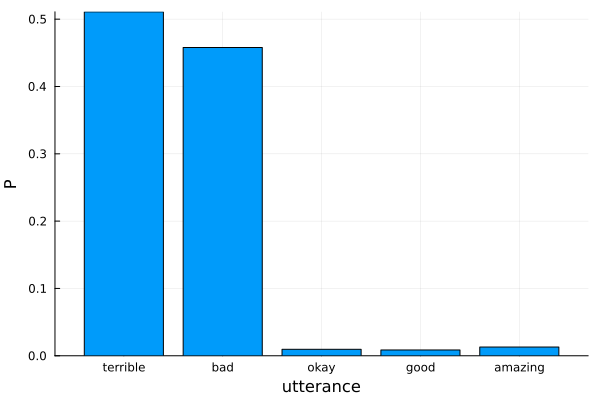

In [8]:
# Precompute L0_map
function L0_posterior(utterance::String)
  tr, _ = generate(literalListener, (stateProbs, utterance), choicemap(:m=>true))
  latents = Dict{Any,Latent}(:state => Latent(states, []))
  obs_meta = Dict{Any,Observation}(:m    => Observation([:state]))
  fg     = compile_trace_to_factor_graph(tr, latents, obs_meta)
  ve_res = variable_elimination(fg, [:state])
  dummy  = Vector{Any}(undef,1)
  return conditional_dist(ve_res.intermediate_fgs[1], dummy, :state)
end

L0_map = Dict(u => L0_posterior(u) for u in utterances)

# New VE-based speaker model that *conditions* on `state`
lambda_ = 1.25
social(proportions, λ) = sum(k*v for (k,v) in zip(states, proportions)) * λ

@gen function speaker1_model(s::Int, φ::Float64)
  probs = Float64[]
  for u in utterances
    post = L0_map[u]          # Vector{P(state | u,m)}
    ue   = log(post[s])       # ONLY the entry for our fixed state
    us   = social(post, lambda_)
    push!(probs, exp(φ*ue + (1-φ)*us))
  end
  probs ./= sum(probs)
  utter ~ uniformDraw(utterances, probs)
  return utter
end

# One VE pass to get P(utterance | state=1, φ=0.99)
tr_sp, _   = generate(speaker1_model, (1, 0.99), choicemap())
latents_sp = Dict{Any,Latent}(:utter => Latent(utterances, []))
obs_meta_sp= Dict{Any,Observation}()

fg_sp      = compile_trace_to_factor_graph(tr_sp, latents_sp, obs_meta_sp)
ve_sp      = variable_elimination(fg_sp, [:utter])
dummy_sp   = Vector{Any}(undef,1)
post_utter = conditional_dist(ve_sp.intermediate_fgs[1], dummy_sp, :utter)

println("Exact P(utter | state=1, φ=0.99):")
for (u,p) in zip(utterances, post_utter)
  @printf("  %-8s → %.4f\n", u, p)
end

bar(utterances, post_utter, xlabel="utterance", ylabel="P", legend=false)


## L1

In [9]:
phiVals = collect(0.05:0.05:0.95)
phiProbs = uniformProbs(phiVals)
utterances = ["terrible", "bad", "okay", "good", "amazing"]

5-element Vector{String}:
 "terrible"
 "bad"
 "okay"
 "good"
 "amazing"

In [10]:
prob(u,s) = literal[u][s]
@dist meaning(u::String,s::Int) = bernoulli(prob(u,s))
@dist catIdx(p)      = categorical(p)
@dist labCat(labels,p)= labels[catIdx(p)]

## L0  P(state | u , m=true)
@gen (static) function L0_listener(u::String)
    s ~ labCat(states, stateProbs)   # :s
    m ~ meaning(u, s)             # :m
    return s
end

function L0_row(u::String)
    tr,_ = generate(L0_listener, (u,), choicemap(:m=>true))
    lat  = Dict{Any,Latent}(
      :s => Latent(collect(1:length(states)), [])
    )
    obs  = Dict{Any,Observation}(
      :m => Observation([:s])
    )
    fg   = compile_trace_to_factor_graph(tr, lat, obs)
    ve   = variable_elimination(fg, [:s])
    conditional_dist(ve.intermediate_fgs[1], Vector{Any}(undef,1), :s)
end

L0_mat = [ L0_row(u) for u in utterances ]  # 5×5 matrix: L0_mat[i][j] = P(s=j | u=i)


# U[s,p,u] = P(u|s,φ)
alpha_ = 10
U = zeros(Float64, length(states), length(phiVals), length(utterances))
for (ui,u) in enumerate(utterances), (si,s) in enumerate(states), (pi,φ) in enumerate(phiVals)
    val = alpha_ * ( φ*log(L0_mat[ui][si])
                    + (1-φ)*(sum(k*v for (k,v) in zip(states,L0_mat[ui])) * lambda_) )
    U[si,pi,ui] = val
end

# softmax over utterances
for si in 1:length(states), pi in 1:length(phiVals)
    row = @view U[si,pi,:]
    row .-= maximum(row)
    row .= exp.(row)
    row ./= sum(row)
end

# Pragmatic listener as static model over indices
@gen (static) function L1_model(obsU::Int)
    sIdx ~ catIdx(stateProbs)
    pIdx ~ catIdx(phiProbs)
    uIdx ~ catIdx(@view U[sIdx,pIdx,:])
    return (sIdx, pIdx)
end

# observe utterance = "good"
obsU = findfirst(==("good"), utterances)
tr,_ = generate(L1_model, (obsU,), choicemap(:uIdx=>obsU))

lat = Dict{Any,Latent}(
    :sIdx => Latent(collect(1:length(states)),  []),
    :pIdx => Latent(collect(1:length(phiVals)), [])
)
obs = Dict{Any,Observation}(
    :uIdx => Observation([:sIdx, :pIdx])
)

fg = compile_trace_to_factor_graph(tr, lat, obs)

# marginal P(state | u)
ve_s  = variable_elimination(fg, [:pIdx, :sIdx])
i_s   = fg.addr_to_idx[:sIdx]
post_s = conditional_dist(ve_s.intermediate_fgs[i_s],
                         Vector{Any}(undef,2), :sIdx)

# marginal P(phi | u)
ve_p  = variable_elimination(fg, [:sIdx, :pIdx])
i_p   = fg.addr_to_idx[:pIdx]
post_p = conditional_dist(ve_p.intermediate_fgs[i_p],
                         Vector{Any}(undef,2), :pIdx)

############# Display #############
println("Exact P(state | \"good\"):")
for (s,p) in zip(states, post_s)
    @printf("  %d → %.4f\n", s, p)
end

println("\nExact P(φ | \"good\"):")
for (i,φ) in enumerate(phiVals)
    @printf("  %.2f → %.4f\n", φ, post_p[i])
end


Exact P(state | "good"):
  1 → 0.0067
  2 → 0.0463
  3 → 0.7355
  4 → 0.1950
  5 → 0.0164

Exact P(φ | "good"):
  0.05 → 0.0058
  0.10 → 0.0181
  0.15 → 0.0523
  0.20 → 0.0872
  0.25 → 0.1010
  0.30 → 0.1055
  0.35 → 0.1047
  0.40 → 0.0956
  0.45 → 0.0825
  0.50 → 0.0672
  0.55 → 0.0510
  0.60 → 0.0371
  0.65 → 0.0278
  0.70 → 0.0233
  0.75 → 0.0225
  0.80 → 0.0241
  0.85 → 0.0272
  0.90 → 0.0313
  0.95 → 0.0360


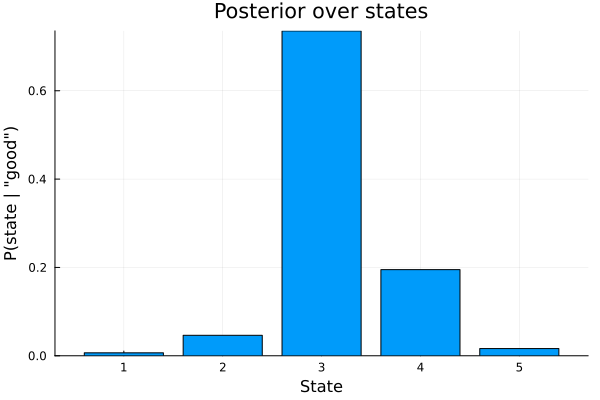

In [11]:
# Bar‐plot for P(state | "good")
p_state = bar(
  states,
  post_s,
  xlabel="State",
  ylabel="P(state | \"good\")",
  legend=false,
  title="Posterior over states"
)

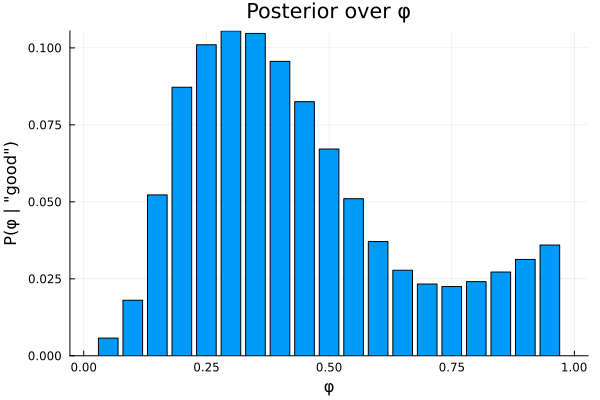

In [12]:
# Bar‐plot for P(φ | "good")
p_phi = bar(
  phiVals,
  post_p,
  xlabel="φ",
  ylabel="P(φ | \"good\")",
  legend=false,
  title="Posterior over φ"
)